# ODMR Single File Fitting and Extraction
This notebook fits the ODMR spectrum from `ODMR_avg_99-6dBm_0mW.csv` using the global Lorentzian triplet model from the fitlorenzo notebook, extracts all parameters needed for the NV left-dip A response matrix, and analyzes the slopes at the leftmost minima of each of the 8 ODMR dips.

## 1. Import Required Libraries and fitlorenzo Functions
Import numpy, pandas, matplotlib, and all necessary fitting functions from the fitlorenzo notebook.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from fitlorenzo_functions import (
    lorentzian, make_global_odmr_model, normalize_signal, smooth_signal,
    validate_frequency_units, detect_8_dip_center_guesses, fit_polynomial_baseline,
    pair_dips_by_symmetry, fit_global_odmr
)


## 2. Load ODMR Data from CSV
Load the `ODMR_avg_99-6dBm_0mW.csv` file using pandas and inspect the data structure.

In [7]:
# Load the ODMR data
csv_path = Path('../data/ODMR_avg_99-6dBm_0mW.csv')
df = pd.read_csv(csv_path, sep='\t')
display(df.head())
print(f"Data shape: {df.shape}")

,Frequency,Pixel(95-95)
0,2.770000e+09,0.077997
1,2.770200e+09,0.077922
2,2.770400e+09,0.077767
3,2.770600e+09,0.077958
4,2.770800e+09,0.078015


Data shape: (1000, 2)


## 3. Fit ODMR Data Using fitlorenzo Functions
Apply the fitting functions from fitlorenzo to the loaded ODMR data to obtain fit parameters.

In [8]:
# Fit the ODMR data using the global Lorentzian triplet model
results_df, pairs_df, payload = fit_global_odmr(df)
display(results_df)
display(pairs_df)
# Show the main fit parameters for onward use
print('Fit parameters:')
print('D_eff_GHz:', payload['D_eff_GHz'])
print('delta_hf_GHz:', payload['delta_hf_GHz'])
print('width_L_GHz:', payload['width_L_GHz'])

,dip_id,dip_side,center_GHz,center_err_MHz,x0_GHz,x1_GHz,x2_GHz,x0_MHz,x1_MHz,x2_MHz,...,hf01_MHz,hf12_MHz,delta_hf_MHz,delta_hf_err_MHz,lorentz_fwhm_MHz,lorentz_fwhm_err_MHz,w_m1,w_0,w_p1,global_fit_rms
0,1,left,2.791167,0.052902,2.788996,2.791167,2.793338,2788.996387,2791.166966,2793.337544,...,2.170578,2.170578,2.170578,0.019252,1.272289,0.036258,0.33952,0.321871,0.338609,0.012153
1,2,left,2.793649,0.287690,2.791479,2.793649,2.795820,2791.478829,2793.649407,2795.819986,...,2.170578,2.170578,2.170578,0.019252,1.272289,0.036258,0.33952,0.321871,0.338609,0.012153
2,3,left,2.803905,0.041097,2.801734,2.803905,2.806075,2801.734071,2803.904650,2806.075228,...,2.170578,2.170578,2.170578,0.019252,1.272289,0.036258,0.33952,0.321871,0.338609,0.012153
3,4,left,2.806465,0.357729,2.804294,2.806465,2.808635,2804.293937,2806.464515,2808.635093,...,2.170578,2.170578,2.170578,0.019252,1.272289,0.036258,0.33952,0.321871,0.338609,0.012153
4,5,right,2.934173,0.026879,2.932003,2.934173,2.936344,2932.002917,2934.173496,2936.344074,...,2.170578,2.170578,2.170578,0.019252,1.272289,0.036258,0.33952,0.321871,0.338609,0.012153
5,6,right,2.940690,0.419626,2.938520,2.940690,2.942861,2938.519744,2940.690322,2942.860901,...,2.170578,2.170578,2.170578,0.019252,1.272289,0.036258,0.33952,0.321871,0.338609,0.012153
6,7,right,2.944968,0.034020,2.942797,2.944968,2.947138,2942.796939,2944.967517,2947.138095,...,2.170578,2.170578,2.170578,0.019252,1.272289,0.036258,0.33952,0.321871,0.338609,0.012153
7,8,right,2.947103,0.198269,2.944932,2.947103,2.949274,2944.932402,2947.102980,2949.273558,...,2.170578,2.170578,2.170578,0.019252,1.272289,0.036258,0.33952,0.321871,0.338609,0.012153


,pair_id,left_dip_id_sorted,right_dip_id_sorted,left_center_x1_GHz,right_center_x1_GHz,left_center_x1_err_MHz,right_center_x1_err_MHz,pair_center_GHz,pair_center_minus_D_eff_MHz,splitting_GHz,splitting_MHz,zeeman_half_MHz,left_contrast,right_contrast,D_eff_GHz
0,1,1,8,2.791167,2.947103,0.052902,0.198269,2.869135,-1.130009,0.155936,155.936015,77.968007,0.283332,0.063065,2.870265
1,2,2,7,2.793649,2.944968,0.287690,0.034020,2.869308,-0.956519,0.151318,151.318110,75.659055,0.041234,0.374527,2.870265
2,3,3,6,2.803905,2.940690,0.041097,0.419626,2.872297,2.032504,0.136786,136.785673,68.392836,0.254305,0.025721,2.870265
3,4,4,5,2.806465,2.934173,0.357729,0.026879,2.870319,0.054024,0.127709,127.708981,63.854490,0.029868,0.358035,2.870265


Fit parameters:
D_eff_GHz: 2.8702649815634294
delta_hf_GHz: 0.0021705783649942777
width_L_GHz: 0.0012722889106978655


## 4. Plot Fitted ODMR Data
Plot the original ODMR data and the fitted curve using matplotlib for visual inspection.

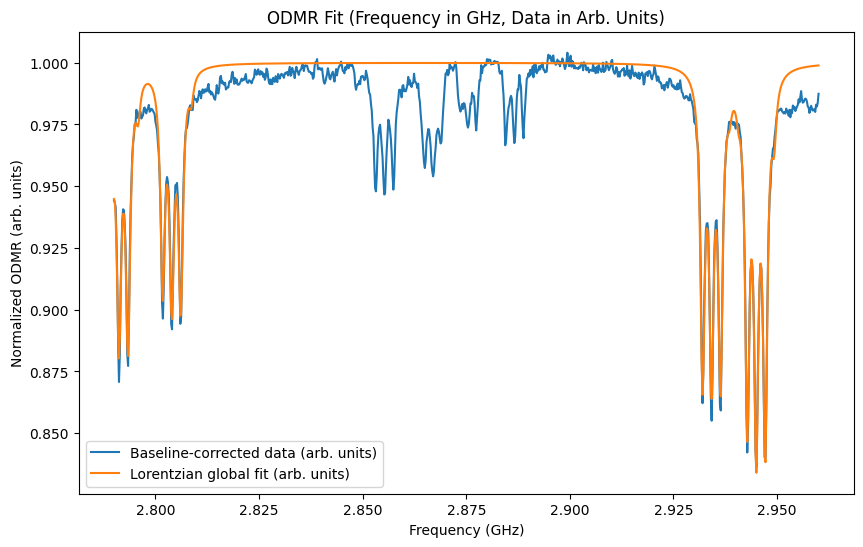

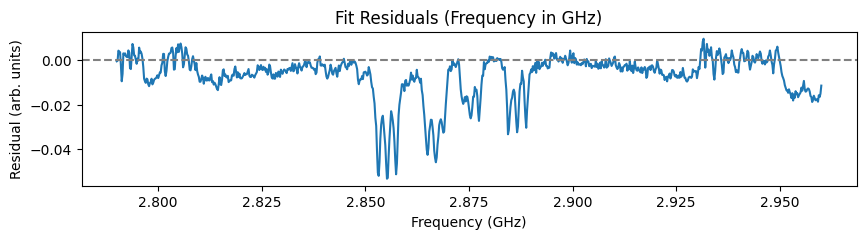

In [9]:
# Plot the baseline-corrected data and the fit
f_ghz = payload['f_ghz']
y_fit = payload['y_fit']
y_model = payload['y_model']
residuals = payload['residuals']

plt.figure(figsize=(10, 6))
plt.plot(f_ghz, y_fit, label='Baseline-corrected data (arb. units)')
plt.plot(f_ghz, y_model, label='Lorentzian global fit (arb. units)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Normalized ODMR (arb. units)')
plt.title('ODMR Fit (Frequency in GHz, Data in Arb. Units)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 2))
plt.plot(f_ghz, residuals, label='Residuals (arb. units)')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Residual (arb. units)')
plt.title('Fit Residuals (Frequency in GHz)')
plt.show()

## 5. Extract Fit Parameters for nv_leftdip A Response Matrix
Extract and organize the fit parameters needed for the nv_leftdip A response matrix.

In [10]:
# Extract parameters for the response matrix
x1_ghz = results_df['x1_GHz'].to_numpy()
x1_err_mhz = results_df['center_err_MHz'].to_numpy()
contrasts = results_df['contrast'].to_numpy()

print('x1 (GHz):', x1_ghz)
print('x1 errors (MHz):', x1_err_mhz)
print('Contrasts:', contrasts)
print('D_eff_GHz:', payload['D_eff_GHz'])
print('delta_hf_MHz:', payload['delta_hf_GHz'] * 1000.0)

# Units are GHz for frequency, MHz for errors, as in the data file

x1 (GHz): [2.79116697 2.79364941 2.80390465 2.80646452 2.9341735  2.94069032
 2.94496752 2.94710298]
x1 errors (MHz): [0.05290214 0.28769035 0.04109688 0.3577293  0.02687933 0.41962632
 0.03402002 0.19826949]
Contrasts: [0.28333165 0.04123411 0.25430451 0.02986844 0.35803493 0.0257206
 0.37452689 0.06306519]
D_eff_GHz: 2.8702649815634294
delta_hf_MHz: 2.170578364994278


## 6. Find Minima of 8 ODMR Dips (Left Side of Each Dip)
Identify the minima corresponding to the left side of each of the 8 ODMR dips, focusing on the first hyperfine dip for each.

In [11]:
# Find minima for the leftmost side (first hyperfine dip) of each ODMR dip
model = make_global_odmr_model()
popt = payload['popt']
f_ghz_dense = np.linspace(f_ghz.min(), f_ghz.max(), 5000)
y_model_dense = model(f_ghz_dense, *popt)

left_minima = []
left_minima_indices = []
for i in range(8):
    x0 = results_df.iloc[i]['x0_GHz']
    window = (np.abs(f_ghz_dense - x0) < 0.0015)  # 1.5 MHz window
    if np.any(window):
        idx_local = np.argmin(y_model_dense[window])
        idx_global = np.where(window)[0][0] + idx_local
        left_minima.append(f_ghz_dense[idx_global])
        left_minima_indices.append(idx_global)
    else:
        left_minima.append(np.nan)
        left_minima_indices.append(None)

print('Left minima positions (GHz):', left_minima)

Left minima positions (GHz): [np.float64(2.7904760952190437), np.float64(2.7911902380476095), np.float64(2.8017663532706543), np.float64(2.8039427885577117), np.float64(2.932012402480496), np.float64(2.9370454090818163), np.float64(2.9428265653130627), np.float64(2.9449689937987595)]


## 7. Calculate and Save Slopes at Minima
Calculate the slope at each identified minimum (left side of each dip) and store these values.

In [12]:
# Calculate the slope (derivative) at each left minimum
slopes = []
for idx in left_minima_indices:
    if idx is not None and 1 < idx < len(f_ghz_dense) - 2:
        slope = (y_model_dense[idx + 1] - y_model_dense[idx - 1]) / (f_ghz_dense[idx + 1] - f_ghz_dense[idx - 1])
        slopes.append(slope)
    else:
        slopes.append(np.nan)

# Display slope values for onward use
print('Slopes at left minima:', slopes)
left_minima_data = {'left_minima_GHz': left_minima, 'slopes': slopes}
left_minima_data

Slopes at left minima: [np.float64(-57.649744084655474), np.float64(-4.506892568794856), np.float64(6.8341429385923265), np.float64(4.040217814228149), np.float64(-3.5349820657063957), np.float64(87.34244296571975), np.float64(6.762279577301967), np.float64(4.067636917597105)]


{'left_minima_GHz': [np.float64(2.7904760952190437),
  np.float64(2.7911902380476095),
  np.float64(2.8017663532706543),
  np.float64(2.8039427885577117),
  np.float64(2.932012402480496),
  np.float64(2.9370454090818163),
  np.float64(2.9428265653130627),
  np.float64(2.9449689937987595)],
 'slopes': [np.float64(-57.649744084655474),
  np.float64(-4.506892568794856),
  np.float64(6.8341429385923265),
  np.float64(4.040217814228149),
  np.float64(-3.5349820657063957),
  np.float64(87.34244296571975),
  np.float64(6.762279577301967),
  np.float64(4.067636917597105)]}

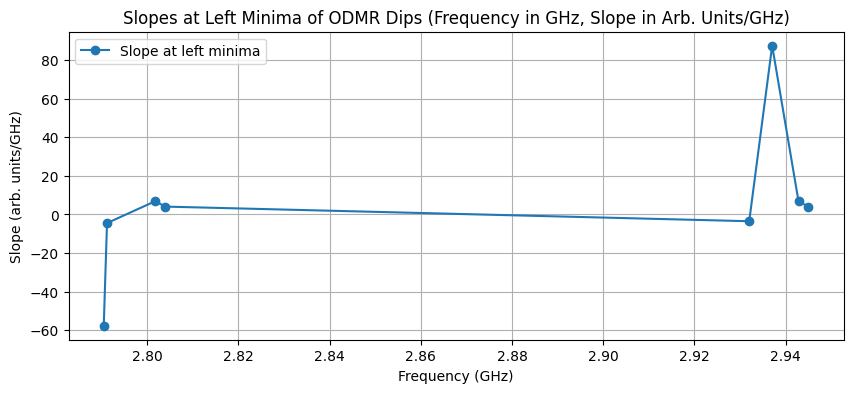

Slopes at left minima (GHz, value):
2.790476 GHz: -5.7650e+01 (arb. units/GHz)
2.791190 GHz: -4.5069e+00 (arb. units/GHz)
2.801766 GHz: 6.8341e+00 (arb. units/GHz)
2.803943 GHz: 4.0402e+00 (arb. units/GHz)
2.932012 GHz: -3.5350e+00 (arb. units/GHz)
2.937045 GHz: 8.7342e+01 (arb. units/GHz)
2.942827 GHz: 6.7623e+00 (arb. units/GHz)
2.944969 GHz: 4.0676e+00 (arb. units/GHz)


In [13]:
# Plot the slopes at the left minima for visual inspection
plt.figure(figsize=(10, 4))
plt.plot(left_minima, slopes, 'o-', label='Slope at left minima')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Slope (arb. units/GHz)')
plt.title('Slopes at Left Minima of ODMR Dips (Frequency in GHz, Slope in Arb. Units/GHz)')
plt.grid(True)
plt.legend()
plt.show()

# Display slope values for onward use
print('Slopes at left minima (GHz, value):')
for freq, slope in zip(left_minima, slopes):
    print(f"{freq:.6f} GHz: {slope:.4e} (arb. units/GHz)")